# Project Overview

The goal of this project is to estimate how NerdWallet's 2025 Super Bowl ad influenced branded search interest using causal inference techniques including:

- **Interrupted Time Series (ITS)**
- **Difference-in-Differences (DiD)**
- **Event Studies**
- **Synthetic Control Methods**

In [1]:
# Import packages for the analysis

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

## Specifying Dates and Loading Data

In [2]:
# Super Bowl date is '2025-02-10' so if prior then this is a placebo test

# Please justify your choices of pre and post-period windows: 
# it should not be "using all dates" by default 
event_date = pd.to_datetime('2025-02-10')
preperiod_length = 90
postperiod_length = 3

# Define the start and end dates for the pre and post event periods:
# Used to subset data prior to estimating the models 
start_date = event_date - pd.DateOffset(days=preperiod_length)
end_date = event_date + pd.DateOffset(days=postperiod_length)

In [3]:
def plot_actual_vs_fitted(data, actual_name, predicted_values, event_start):
    plt.figure(figsize=(10, 6))
    plt.plot(data['date'], data[actual_name], label='Actual Value', color='b')
    plt.plot(data['date'], predicted_values, label='fitted line', color='red', alpha=0.7)
    plt.axvline(event_start, color='gray', linestyle='--', alpha=0.5)
    plt.text(event_start+pd.Timedelta(days=1), max(data[actual_name]), 'Event Date', fontsize=10, color='gray')
    plt.legend(loc='upper left')
    plt.xlabel('Dates')
    plt.ylabel('Searches')
    plt.title('Actual Value vs Model Prediction')
    plt.show()

### About This Data

Google Trends data is normalized from 0-100, where 100 represents peak search interest during the selected time window.

- `date`: Date of observation in ISO 8601 format (YYYY-MM-DD), e.g. `2025-01-31`
- `nerdwallet`: Direct search interest for "NerdWallet"
- `credit_card_points`, `travel_credit_card`, `best_savings_account`: Search interest for other queries related to NerdWallet, to help control for seasonality

In [4]:
# Load the data
df = pd.read_csv('nerdwallet.csv', skiprows=3, names=["date", "nerdwallet", "credit_card_points", "travel_credit_card", "best_savings_account"])
df.head()

,date,nerdwallet,credit_card_points,travel_credit_card,best_savings_account
0,2024-11-01,47,43,42,55
1,2024-11-02,42,45,44,37
2,2024-11-03,41,39,47,29
3,2024-11-04,41,49,45,44
4,2024-11-05,38,42,42,39


## Time Series Plot of Each Keyword

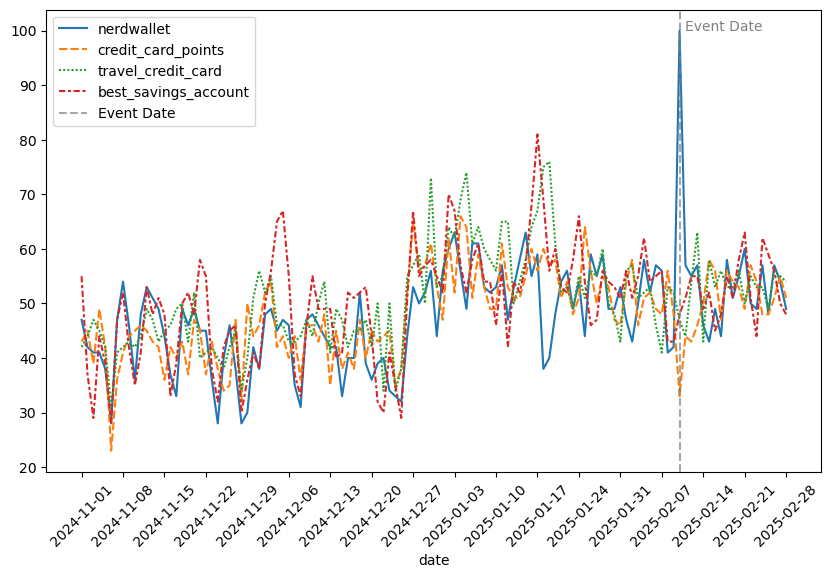

In [5]:
# TODO: Create a plot of the time series for each keyword

df_index = df.set_index('date').copy()

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_index)
step = 7
plt.xticks(df_index.index[::step], rotation=45)
plt.axvline('2025-02-10', linestyle='--', color='gray', alpha=0.7, label='Event Date')
plt.text('2025-02-11', df_index['nerdwallet'].max(), 'Event Date', fontsize=10, color='gray')
plt.legend(loc='upper left')
plt.show()

In [6]:
df['date']=pd.to_datetime(df['date'])
subset =df[(df['date']>=start_date)&(df['date']<end_date)].copy()
subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93 entries, 11 to 103
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  93 non-null     datetime64[ns]
 1   nerdwallet            93 non-null     int64         
 2   credit_card_points    93 non-null     int64         
 3   travel_credit_card    93 non-null     int64         
 4   best_savings_account  93 non-null     int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 4.4 KB


## Interrupted Time Series (ITS) Modeling

In [7]:
# TODO: ITS modeling

subset['t']=np.arange(1, len(subset)+1)
t_0 = subset[subset['date']==event_date]['t'].values[0]
subset['trend']=subset['t']-t_0
subset['post']=np.where(subset['trend']>=0, 1, 0)
subset['interaction']=subset['post']*subset['trend']

its_model=smf.ols(formula='nerdwallet~trend+post+interaction', data=subset).fit()
print(its_model.summary())

                            OLS Regression Results                            
Dep. Variable:             nerdwallet   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     22.63
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           5.60e-11
Time:                        15:03:32   Log-Likelihood:                -320.51
No. Observations:                  93   AIC:                             649.0
Df Residuals:                      89   BIC:                             659.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      53.9338      1.650     32.679      

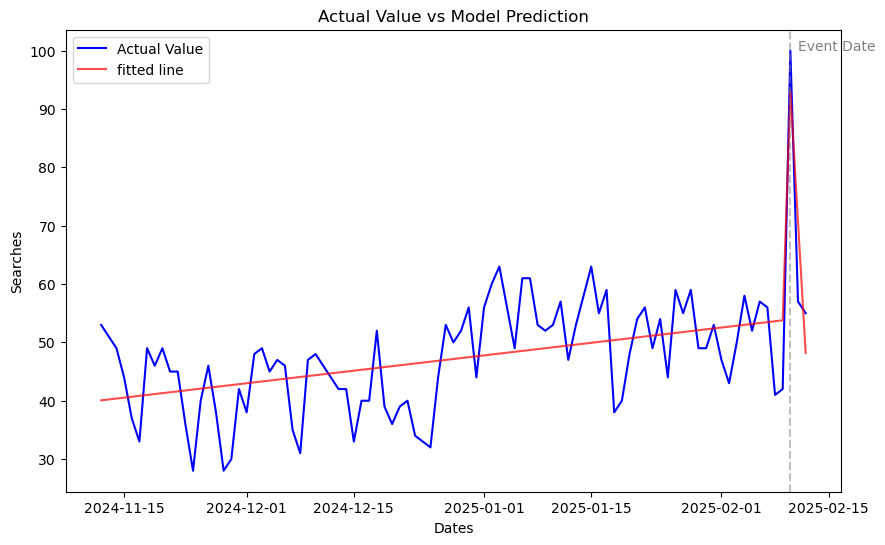

In [8]:
predicted = its_model.fittedvalues
plot_actual_vs_fitted(subset, 'nerdwallet', predicted, event_date)

In [9]:
beta2=its_model.params['post']
beta3=its_model.params['interaction']
ae_att = subset['post']*beta2+subset['interaction']*beta3
ae = ae_att.sum()/subset['post'].sum()
print(f'Average Daily Effect: {ae:.2f}')

Average Daily Effect: 16.58


**Observation**

- The immediate effect of the event shows a jump of nerdwallet search of 33 points increase. However, the growth rate has dropped by 13.25 points, showing less searched than before the event. Both coefficients have P value less than 0.001, showing a significant result.
- However, the time trends are noisy as plotted. It's not linear. The model has R-squared with only 0.40, explaining only 40% of the variances of the response variable. We can try to use other models while the time trends are noisy. 

## Difference-in-Differences (DiD) Modeling

In [10]:
group_cols = ['nerdwallet', 'credit_card_points', 'travel_credit_card', 'best_savings_account']

subset_melt = pd.melt(subset, id_vars='date', value_vars=group_cols, var_name='group', value_name='search')

subset_melt['treated']=np.where(subset_melt['group']=='nerdwallet', 1, 0)
subset_melt['post']=np.where(subset_melt['date']>=event_date, 1, 0)
subset_melt['interaction']=subset_melt['treated']*subset_melt['post']

did_model=smf.ols(formula='search~treated+post+interaction', data=subset_melt).fit()
print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 search   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     8.515
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           1.76e-05
Time:                        15:03:32   Log-Likelihood:                -1348.4
No. Observations:                 372   AIC:                             2705.
Df Residuals:                     368   BIC:                             2721.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      50.1370      0.555     90.258      

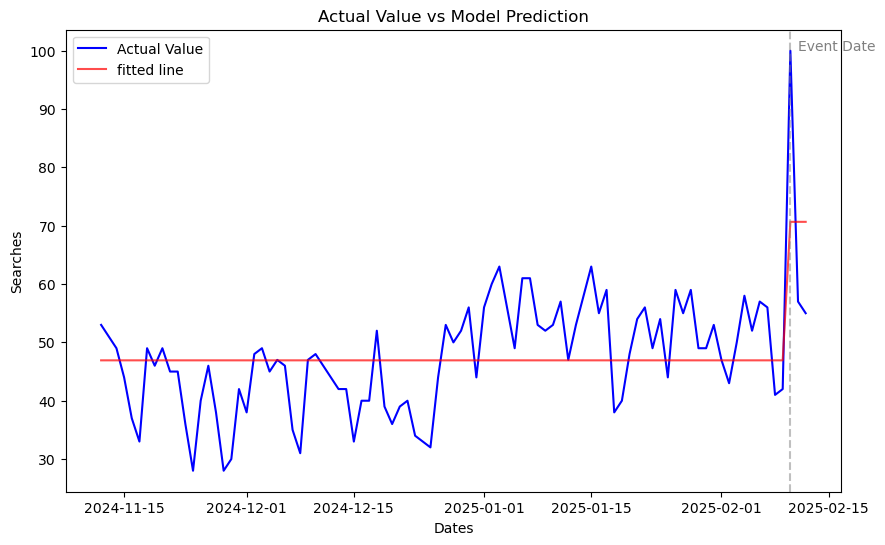

In [11]:
subset_melt['fitted']=did_model.fittedvalues
predicted=subset_melt[subset_melt['group']=='nerdwallet']['fitted']

plot_actual_vs_fitted(subset, 'nerdwallet', predicted, event_date)

In [12]:
did_effect = did_model.params['interaction']*subset_melt['interaction']

ae = did_effect.sum()/subset_melt['interaction'].sum()
print(f'Average Daily Effect: {ae:.2f}')

Average Daily Effect: 27.33


**Observation**:

- The treated group 'NerWallet' has a significant increase of 22 points in comparison of other non-nerwallet groups.

### Testing the model assumptions of DID:
- parallel trend before the event (Take the pre-event data, and test the interaction term)

In [13]:
subset_melt_pre_event = subset_melt[subset_melt['date']<event_date].copy()
subset_melt_pre_event['trend']=(subset_melt_pre_event['date']-event_date).dt.days
subset_melt_pre_event['treated_trend']=subset_melt_pre_event['treated']*subset_melt_pre_event['trend']
its_pre_model=smf.ols(formula='search~trend+treated+treated_trend', data=subset_melt_pre_event).fit()
print(its_pre_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 search   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     35.97
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           2.50e-20
Time:                        15:03:32   Log-Likelihood:                -1257.5
No. Observations:                 360   AIC:                             2523.
Df Residuals:                     356   BIC:                             2539.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        57.4987      0.982     58.544

**Observation**

- Here it shows the interaction 'treated_trend' coefficient is very small and its corresponding P value is insignificant, we can conclude that the pre-event trends are parallel.

### Placebo test of the DID model:

In [14]:
placebo_event_date = pd.to_datetime('2025-01-01')
placebo_start_date = pd.to_datetime('2024-10-01')
placebo_end_date = pd.to_datetime('2025-01-04')

placebo_subset=df[(df['date']>=placebo_start_date)&(df['date']<placebo_end_date)]
placebo_subset_melt=pd.melt(placebo_subset, id_vars=['date'], value_vars=group_cols, var_name='group', value_name='search')
placebo_subset_melt['treated']=np.where(placebo_subset_melt['group']=='nerdwallet', 1, 0)
placebo_subset_melt['post']=np.where(placebo_subset_melt['date']>=placebo_event_date, 1, 0)
placebo_subset_melt['treated_post']=placebo_subset_melt['treated']*placebo_subset_melt['post']

placebo_did = smf.ols(formula='search~treated+post+treated_post', data=placebo_subset_melt).fit()
print(placebo_did.summary())

                            OLS Regression Results                            
Dep. Variable:                 search   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     15.87
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           1.75e-09
Time:                        15:03:32   Log-Likelihood:                -884.78
No. Observations:                 256   AIC:                             1778.
Df Residuals:                     252   BIC:                             1792.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       44.9672      0.571     78.694   

**Observation**

- Here with the placebo event date, we can see the interaction term 'treated_post' is insignificant. Our model can detect the actual event effects on the actual event date and shows insignificant results on the placebo event dates.

## Difference-in-Differences Modeling with Controls

In [15]:
# TODO: DiD modeling with controls
did_twfe = smf.ols(
    formula="search ~ treated*post + C(date) + C(group) - 1",
    data=subset_melt
).fit()
print(did_twfe.summary())

                            OLS Regression Results                            
Dep. Variable:                 search   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     6.809
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           3.34e-36
Time:                        15:03:32   Log-Likelihood:                -1134.6
No. Observations:                 372   AIC:                             2463.
Df Residuals:                     275   BIC:                             2843.
Df Model:                          96                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

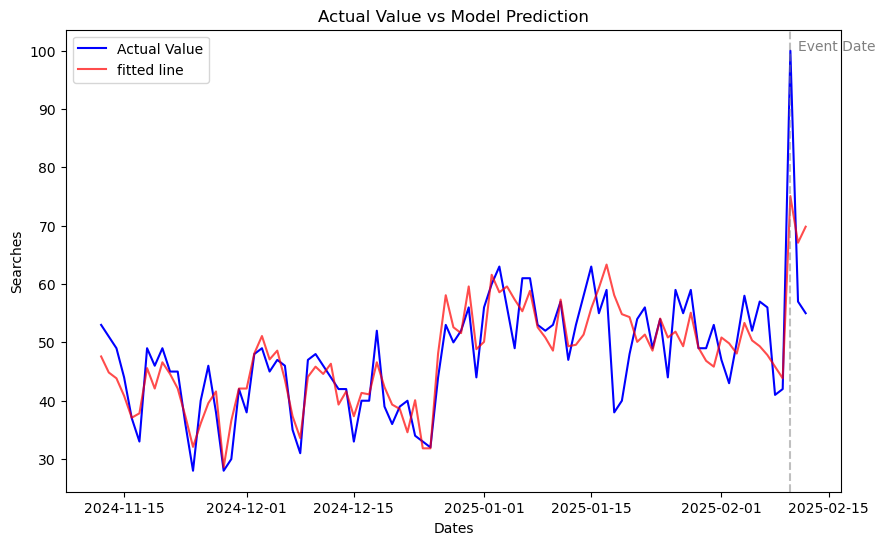

Average Daily Effect: 27.33


In [16]:
subset_melt['fitted']=did_twfe.fittedvalues
predicted=subset_melt[subset_melt['group']=='nerdwallet']['fitted']
plot_actual_vs_fitted(subset, 'nerdwallet', predicted, event_date)

ae=did_twfe.params['treated:post']
print(f'Average Daily Effect: {ae:.2f}')

In [17]:
# improvement on twfe model
did_twfe = smf.ols(
    formula="search ~ post + treated:post + C(date) + C(group) - 1",
    data=subset_melt
).fit()

print(did_twfe.summary())

                            OLS Regression Results                            
Dep. Variable:                 search   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     6.809
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           3.34e-36
Time:                        15:03:32   Log-Likelihood:                -1134.6
No. Observations:                 372   AIC:                             2463.
Df Residuals:                     275   BIC:                             2843.
Df Model:                          96                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

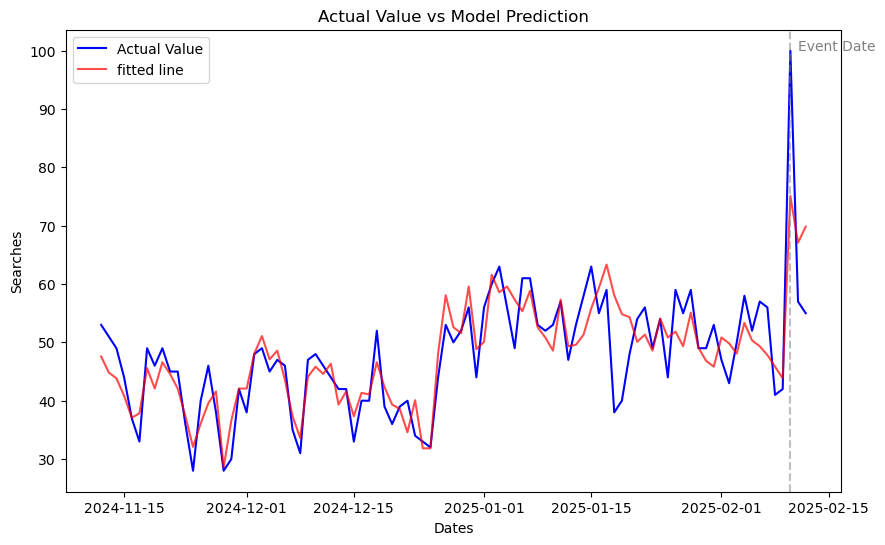

Average Daily Effect: 27.33


In [18]:
subset_melt['fitted']=did_twfe.fittedvalues
predicted=subset_melt[subset_melt['group']=='nerdwallet']['fitted']
plot_actual_vs_fitted(subset, 'nerdwallet', predicted, event_date)

ae=did_twfe.params['treated:post']
print(f'Average Daily Effect: {ae:.2f}')

**observation**:

- Controlling for daily shocks and keyword-specific baselines, the event caused a statistically significant increase of ~22 daily searches for “nerdwallet”, relative to comparable finance-related search terms.
- The effect is large, precise, and robust within a TWFE DiD framework.

## Event Study Modeling

In [19]:
# TODO: Event study modeling

subset['pre3']=np.where(subset['trend']==-3, 1, 0)
subset['pre2']=np.where(subset['trend']==-2, 1, 0)
subset['pre1']=np.where(subset['trend']==-1, 1, 0)
subset['post0']=np.where(subset['trend']==0, 1, 0)
subset['post1']=np.where(subset['trend']==1, 1, 0)
subset['post2']=np.where(subset['trend']==2, 1, 0)
# subset['post3']=np.where(subset['trend']==3, 1, 0)

ev_model = smf.ols(formula='nerdwallet~credit_card_points+travel_credit_card+best_savings_account+pre3+pre2+pre1+post0+post1+post2', data=subset).fit()
print(ev_model.summary())

                            OLS Regression Results                            
Dep. Variable:             nerdwallet   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     20.70
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           8.29e-18
Time:                        15:03:32   Log-Likelihood:                -292.14
No. Observations:                  93   AIC:                             604.3
Df Residuals:                      83   BIC:                             629.6
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                8.9994 

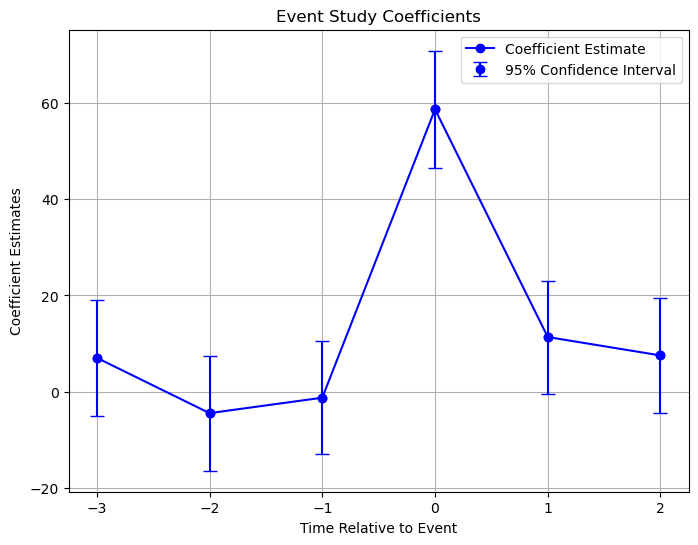

In [20]:
coefficients = ev_model.params.index[-6:]
x_values=np.arange(-3, 3)
y_values = [ev_model.params[coef] for coef in coefficients]

y_err = [1.96*ev_model.bse[coef] for coef in coefficients]

plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, marker='o', color='b', label='Coefficient Estimate')
plt.errorbar(x_values, y_values, y_err, color='b',fmt='o', capsize=5, label='95% Confidence Interval')
plt.xlabel('Time Relative to Event')
plt.ylabel('Coefficient Estimates')
plt.xticks(x_values)
plt.title('Event Study Coefficients')
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

**Observation**

- most of the pre & post coefficients have p-values greater than 0.17, except the post1 period with a P value 0.06, which indicate a smaller impact right after the event date.
- about ~59 more searches on nerwallet than other terms, but since the post event impact is decaying and insignificant, the jump is likely happening only on the event date itself and it's a one-off increase.

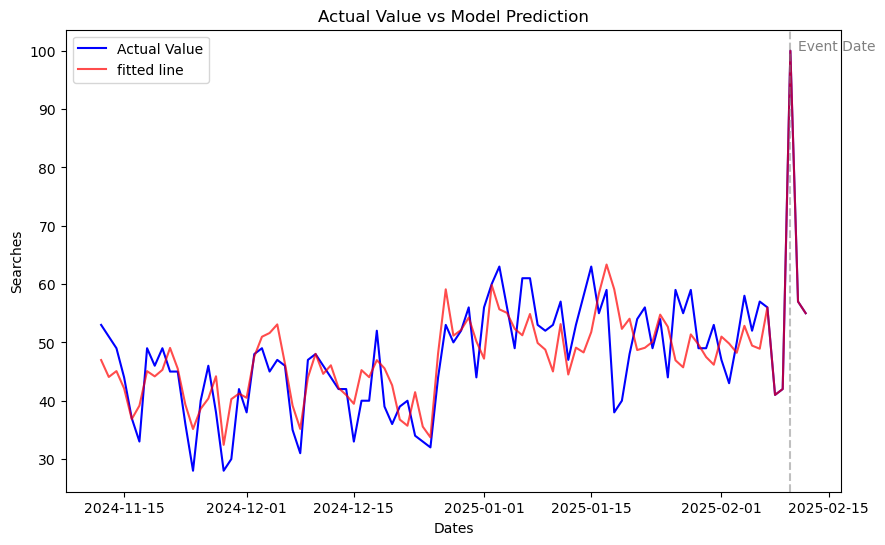

In [21]:
predicted=ev_model.fittedvalues
plot_actual_vs_fitted(subset, 'nerdwallet', predicted, event_date)

In [22]:
# Get the post event treatment effects

ae = ev_model.params[-3:].mean()
print(f'Average Daily Effect: {ae:.2f}')

Average Daily Effect: 25.84


## Estimating a Synthetic Control using Lasso

In [23]:
# TODO: Estimating a synthetic control using Lasso

preperiod=subset[subset['date']<event_date]
control_cols=['credit_card_points','travel_credit_card', 'best_savings_account']
test_col='nerdwallet'

lasso_model = Lasso(alpha=1) 
lasso_model.fit(preperiod[control_cols], preperiod[test_col])
lasso_coefs = pd.Series(lasso_model.coef_, index=control_cols)
print(lasso_coefs)

credit_card_points      0.262227
travel_credit_card      0.000385
best_savings_account    0.477833
dtype: float64


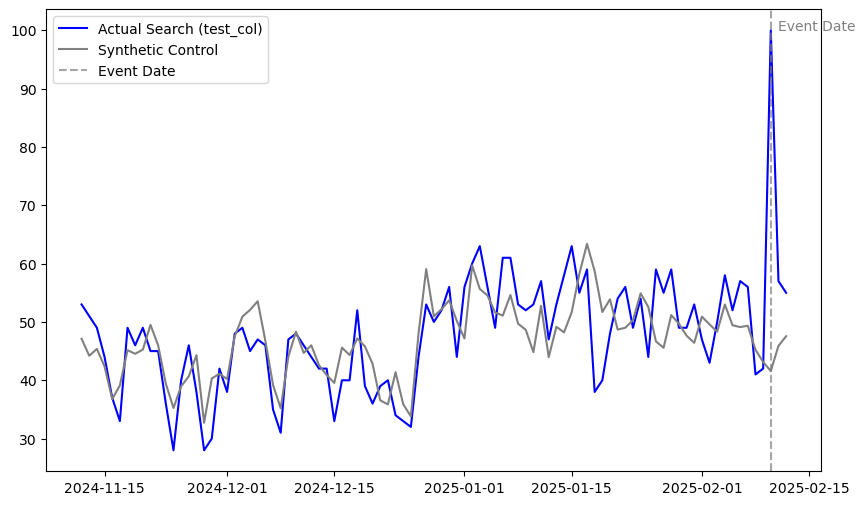

In [24]:
subset['Synthetic_Control']=subset[control_cols].dot(lasso_coefs)+lasso_model.intercept_

plt.figure(figsize=(10, 6))
plt.plot(subset['date'], subset[test_col], color='b', label=f'Actual Search (test_col)')
plt.plot(subset['date'], subset['Synthetic_Control'], color='gray', label='Synthetic Control')
plt.axvline(event_date, color='gray', linestyle='--', alpha=0.7, label='Event Date')
plt.text(event_date+pd.Timedelta(days=1), max(subset[test_col]), 'Event Date', fontsize=10, color='gray')
plt.legend(loc='upper left')
plt.show()

In [25]:
postperiod = subset[subset['date']>=event_date]
att = np.mean(postperiod[test_col]-postperiod['Synthetic_Control'])
att_pct = att/postperiod['Synthetic_Control'].mean()

print(f'Average Uplift: {att:.3f}')
print(f'% of Uplift from Baseline: {att_pct:.3%}')

Average Uplift: 25.655
% of Uplift from Baseline: 56.995%


## Optimizing with Cross-Validation

In [26]:
# TODO: Optimizing with cross-validation

preperiod=subset[subset['date']<event_date]
control_cols=['credit_card_points','travel_credit_card', 'best_savings_account']
test_col='nerdwallet'

lasso_model = LassoCV(cv=5, random_state=42)

lasso_model.fit(preperiod[control_cols], preperiod[test_col])
lasso_coefs = pd.Series(lasso_model.coef_, index=control_cols)
print(lasso_coefs)


credit_card_points      0.244303
travel_credit_card      0.000000
best_savings_account    0.471802
dtype: float64


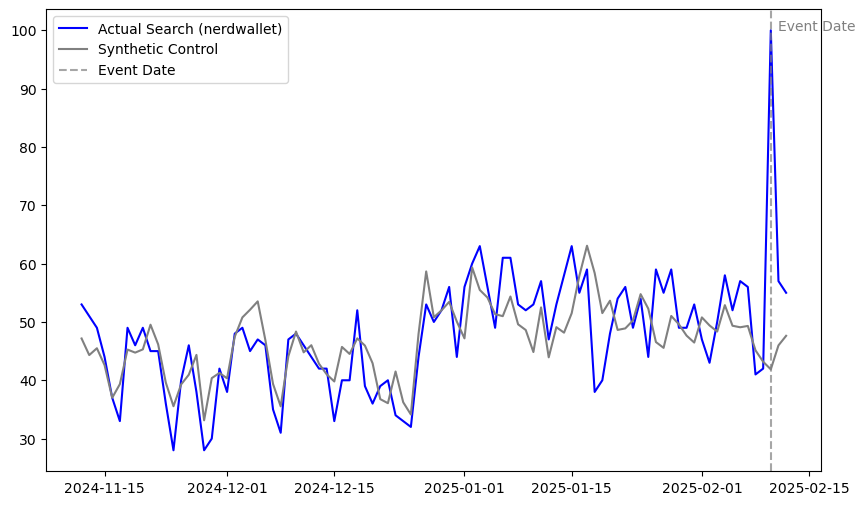

In [27]:
subset['Synthetic_Control']=subset[control_cols].dot(lasso_coefs)+lasso_model.intercept_

plt.figure(figsize=(10, 6))
plt.plot(subset['date'], subset[test_col], color='b', label=f'Actual Search ({test_col})')
plt.plot(subset['date'], subset['Synthetic_Control'], color='gray', label='Synthetic Control')
plt.axvline(event_date, color='gray', linestyle='--', alpha=0.7, label='Event Date')
plt.text(event_date+pd.Timedelta(days=1), max(subset[test_col]), 'Event Date', fontsize=10, color='gray')
plt.legend(loc='upper left')
plt.show()

In [28]:
postperiod = subset[subset['date']>=event_date]
att = np.mean(postperiod[test_col]-postperiod['Synthetic_Control'])
att_pct = att/postperiod['Synthetic_Control'].mean()

print(f'Average Uplift: {att:.3f}')
print(f'% of Uplift from Baseline: {att_pct:.3%}')

Average Uplift: 25.508
% of Uplift from Baseline: 56.484%


## If necessary, net out pre-period differences using a Difference-in-Differences Model

#### Note: In some cases, the synthetic control may have a poor pre-period fit, or a different pre-treatment average outcome than the treated group. In those cases, you may wish to net out the pre-period differences using a DiD model.  If the pre-period fit is very close, then this step is not necessary; simply compare post-treatment outcomes. 

#### Important: The DiD model underestimates the standard error for synthetic control models and should NOT be used to determine statistical significance. The permutation tests below are for statistical significance and confidence intervals

In [29]:
# TODO: If necessary, DiD modeling with synthetic control 
# or justify why not necessary (e.g. similar pre-treatment average outcome)

df_long = pd.melt(subset, id_vars='date', value_vars=['nerdwallet', 'Synthetic_Control'], var_name='Group', value_name='Search')
df_long['treated']=np.where(df_long['Group']=='nerdwallet', 1, 0)
df_long['post']=np.where(df_long['date']>=event_date, 1, 0)
df_long['post_treated']=df_long['treated']*df_long['post']

did_model_with_control=smf.ols(formula='Search~post_treated+C(date)+C(Group)-1', data=df_long).fit()
print(did_model_with_control.summary())

                            OLS Regression Results                            
Dep. Variable:                 Search   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     4.403
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           5.51e-12
Time:                        15:03:33   Log-Likelihood:                -497.66
No. Observations:                 186   AIC:                             1185.
Df Residuals:                      91   BIC:                             1492.
Df Model:                          94                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

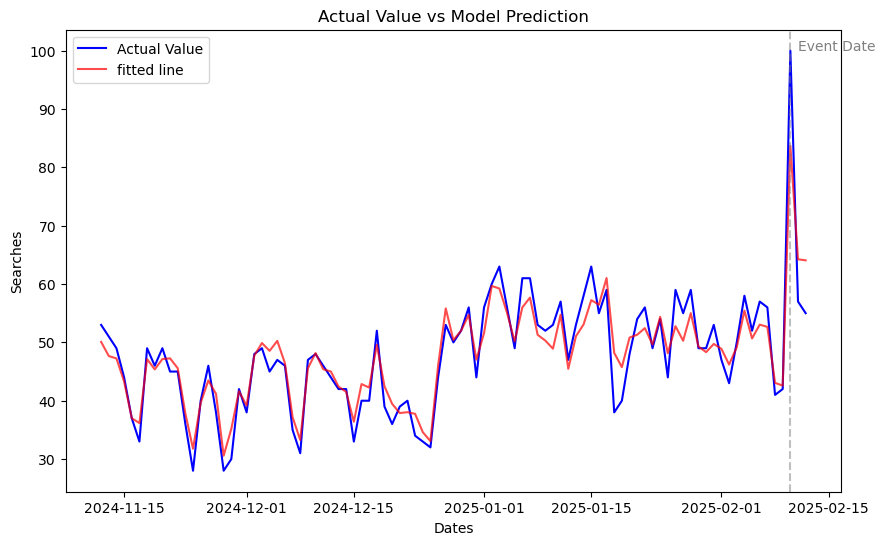

Average Uplift: 25.508
% of Uplift from Baseline: 56.484%


In [30]:
df_long['fitted']=did_model_with_control.fittedvalues
predicted=df_long[df_long['Group']=='nerdwallet']['fitted']
plot_actual_vs_fitted(subset, 'nerdwallet', predicted, event_date)

att = did_model_with_control.params['post_treated']
att_baseline = (df_long[df_long['post_treated']==1]['Search']).mean()-att
att_pct = att/att_baseline

print(f'Average Uplift: {att:.3f}')
print(f'% of Uplift from Baseline: {att_pct:.3%}')

## Permutation Testing

#### Note: Obtaining confidence intervals for synthetic controls is a rapidly growing and changing field. At the time of this course, a common approach to determine statistical significance is via permutation testing.  

#### Whether you simply compared post-treatment outcomes or netted out pre-period differences using DiD, be consistent and run the same model structure for the permutation tests

In [31]:
# TODO: Permutation testing

def get_synthetic_att(data, control_cols, test_name, event_start):
    preperiod=data[data['date']<event_start]
    lasso_model = LassoCV(cv=5, random_state=42)
    lasso_model.fit(preperiod[control_cols], preperiod[test_name])
    lasso_coefs = pd.Series(lasso_model.coef_, index=control_cols)
    data['synthetic_control']=data[control_cols].dot(lasso_coefs)+lasso_model.intercept_
    data['treatment_effect']=data[test_name]-data['synthetic_control']
    att=data[data['date']>=event_start]['treatment_effect'].mean()
    
    return att

In [32]:
control_groups = ['credit_card_points','travel_credit_card', 'best_savings_account']
att_list = []

for placebo_test in control_groups:
    new_control = [g for g in control_groups if g!= placebo_test]
    placebo_att = get_synthetic_att(subset, new_control, placebo_test, event_date)
    att_list.append(placebo_att)

print(att_list)

[-6.618879286031067, 4.009350412444273, 5.0794330336863]


In [33]:
epirical_p=(att_list>att).sum()/len(att_list)
print(f'Epirical P Values: {epirical_p:.2%}')

Epirical P Values: 0.00%


## Final Model Selection and Rationale

TODO: final model selection and rationale

- Except **ITS model, the rest of the selected models have similar average treatment effect**, about 25~27 average increase. The ITS model shows the average treatment effect for about 16, which is a lot less than other models. ITS is not the best choice for this project, because ITS assumes a relatively smooth linear trend, while the data exhibit substantial noise and do not follow a clear linear pattern.
- The **DiD models** (with and without controls) report an **ATT of 27.33**, while both the **Event Study** and **Synthetic Control** models estimate an ATT of approximately **25.8**. These estimates are highly consistent with one another, reinforcing confidence in the magnitude of the effect. Among all specifications, the **Synthetic Control with Lasso + DiD** model performs best in terms of fit, with an **R-squared of 0.82**, compared to roughly **0.6–0.7** for the other models. The fitted values closely track the historical data, largely due to the inclusion of date fixed effects.
- Overall, the **Synthetic Control with Lasso + DiD** is the winner for this project, with an average treatment effect of 25.5, an uplift of ~56% from the baseline.

## Sensitivity Tests:  

#### For your chosen final model, adjust at least one hyperparameter (such as pre-period window length) and ensure that the results aren't very sensitive to reasonable model choices

In [34]:
# TODO: Sensitivity Testing
# Changing the preperiod window to 60 days instead of 90 days
# fit the interrupted time series model again to check the result

event_date = pd.to_datetime('2025-02-10')
preperiod_length = 60
postperiod_length = 3

# Define the start and end dates for the pre and post event periods:
# Used to subset data prior to estimating the models 
start_date = event_date - pd.DateOffset(days=preperiod_length)
end_date = event_date + pd.DateOffset(days=postperiod_length)

                            OLS Regression Results                            
Dep. Variable:             nerdwallet   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     15.64
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           1.35e-07
Time:                        15:03:33   Log-Likelihood:                -217.84
No. Observations:                  63   AIC:                             443.7
Df Residuals:                      59   BIC:                             452.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      54.9452      2.075     26.473      

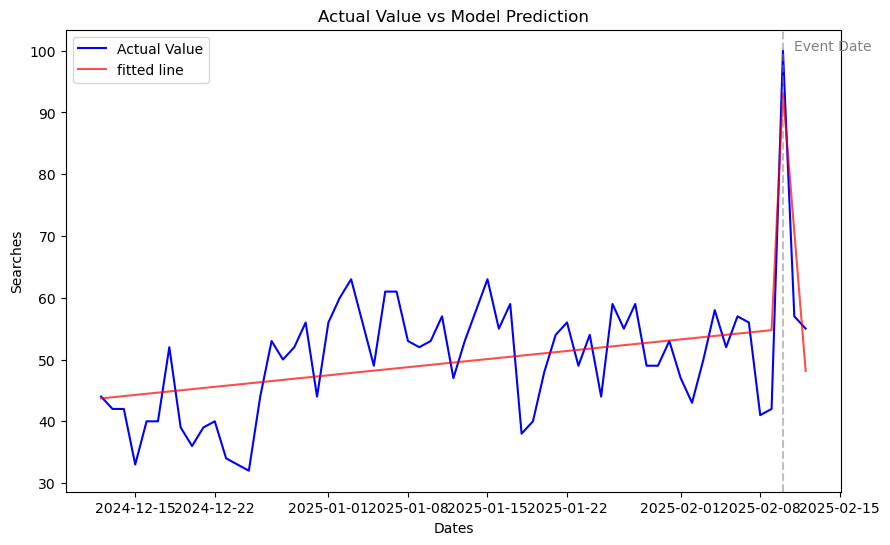

Average Daily Effect: 15.53


In [35]:
# TODO: ITS modeling

subset = df[(df['date']>=start_date)&(df['date']<end_date)].copy()
subset['t']=np.arange(1, len(subset)+1)
t_0 = subset[subset['date']==event_date]['t'].values[0]
subset['trend']=subset['t']-t_0
subset['post']=np.where(subset['trend']>=0, 1, 0)
subset['interaction']=subset['post']*subset['trend']

its_model=smf.ols(formula='nerdwallet~trend+post+interaction', data=subset).fit()
print(its_model.summary())

predicted = its_model.fittedvalues
plot_actual_vs_fitted(subset, 'nerdwallet', predicted, event_date)

beta2=its_model.params['post']
beta3=its_model.params['interaction']
ae_att = subset['post']*beta2+subset['interaction']*beta3
ae = ae_att.sum()/subset['post'].sum()
print(f'Average Daily Effect: {ae:.2f}')

**Observation**

- The att drops 1 point, from 16.58 to 15.53.

## Key Takeaways for Stakeholders

#### The idea here: Imagine your stakeholders are comfortable with randomized experiments but not with observational causal inference.  What have you done so far in this project to help them feel comfortable that this is actually a reasonable causal estimate?

TODO: key takeaways for stakeholders

## Report

### 1. Summary of Findings

We estimate that the ad delivered on Super Bowl night increased searches for **NerdWallet** by approximately **25.6 units per day on average**. This effect is large relative to the pre-event baseline and is **statistically significant**, indicating a meaningful lift attributable to the ad rather than normal fluctuations.

---

### 2. Modeling Approach

- **Interrupted Time Series (ITS)**  
  We first applied an ITS model using a **90-day pre-event window** and a **3-day post-event window** (including Day 0).  
  - Results show an immediate increase of roughly **+39 units** on the event date, followed by a **post-event downward trend** of about **−22 units**.  
  - The implied **average treatment effect (ATE)** is approximately **+16 units per day**.  
  - To test sensitivity, we repeated the analysis using a **60-day pre-event window**. The estimated ATE remains very similar (**~15 units**), suggesting the results are **stable across reasonable time windows**.

- **Difference-in-Differences (DiD) with Controls**  
  We then treated NerdWallet searches as the treated group and all other search terms as control groups.  
  - We explicitly tested DiD assumptions, including **no pre-treatment effects**, and ran **placebo tests** using fake event dates.  
  - All diagnostics support the validity of the DiD setup.  
  - The estimated **average treatment effect is ~27.3 units**.  
  - A DiD model with **two-way fixed effects (dates and search terms)** fits the observed data more closely than a model without fixed effects. Importantly, the estimated treatment effect remains essentially unchanged, indicating the result is **not sensitive to the inclusion of fixed effects**.

- **Event Study**  
  We ran an event study by including indicators for several days before and after the event.  
  - There is **no evidence of anticipatory effects** prior to the event.  
  - A sharp and significant uplift appears **on the event date itself**.  
  - The effect is largely **one-off** and does not persist in the days following the event.

- **Synthetic Control with Lasso**  
  Because a randomized experiment is not feasible (e.g., we cannot randomize Super Bowl viewers), we constructed a **synthetic control** using a weighted combination of other search terms, estimated via **Lasso with cross-validation**.  
  - The synthetic control closely matches pre-event behavior and shows a post-event uplift of about **+25.8 units** for NerdWallet relative to its counterfactual.  
  - Given some non-parallel pre-event gaps, we complemented this with a DiD framework to more cleanly isolate the treatment effect.

- **Combined Synthetic Control + DiD with Controls (Preferred Model)**  
  Finally, we combined the weighted synthetic control with a **DiD model including two-way fixed effects** (search terms and dates).  
  - This model yields an **average treatment effect of ~25.5 units** and an **R-squared of ~0.80**, the highest among all specifications.  
  - The fitted values closely track historical data, increasing confidence in the counterfactual and inferences for the post-event period.

---

### 3. Robustness Checks Supporting the Causal Claim

- **Pre-trends validation**  
  Across DiD and event study specifications, there is no evidence of treatment effects prior to the event.

- **Placebo tests (fake dates and fake treated groups)**  
  Permutation-style placebo tests—rotating treated and control groups in the synthetic control setup—show that effects of this magnitude are extremely unlikely to arise by chance (empirical p-value ≈ 0, given the available placebo groups).

- **Sensitivity to time windows**  
  Varying the pre-event window in the ITS model (90 vs. 60 days) produces very similar estimates, indicating the results are **robust to reasonable modeling choices**.

---

### 4. What This Means for the Business

The Super Bowl ad generated a **clear, measurable, and causal increase** in NerdWallet search interest. Across multiple independent methods, the estimated lift consistently falls in the **~25–26 additional searches per day** range.

From a business perspective, this implies that:
- The ad successfully drove **incremental brand demand**, not just noise or short-term volatility.
- The impact is **immediate and concentrated around the event**, consistent with how high-profile, one-time media exposures typically perform.

Overall, the convergence of results across methods and robustness checks provides strong confidence that the observed lift is **real, causal, and economically relevant**.
